In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib


In [4]:
df = pd.read_csv("../data/processed/SWaT_cleaned.csv")
print(df["Normal/Attack"].value_counts())

Normal/Attack
0    892112
1     54621
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["Normal/Attack", "Timestamp"])
y = df["Normal/Attack"]

print(X.shape)
print(y.value_counts())

(946733, 44)
Normal/Attack
0    892112
1     54621
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
print("Train labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Train labels:
Normal/Attack
0    713689
1     43697
Name: count, dtype: int64

Test labels:
Normal/Attack
0    178423
1     10924
Name: count, dtype: int64


In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 16.332677300501178


In [9]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [10]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
y_pred_xgb = xgb_model.predict(X_test)

In [12]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    178423
           1       0.94      1.00      0.97     10924

    accuracy                           1.00    189347
   macro avg       0.97      1.00      0.98    189347
weighted avg       1.00      1.00      1.00    189347



XGBoost:
[[177673    750]
 [    29  10895]]


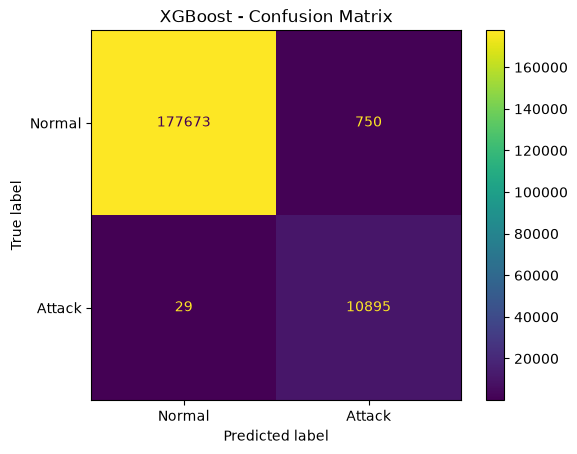

In [13]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("XGBoost:")
print(cm_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Normal", "Attack"]
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.savefig("../images/xgboost_confusion_matrix.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [14]:
# XGBoost Results
#
# XGBoost achieved excellent performance on the test set.
# For the minority Attack class (1), the model achieved:
# Precision = 0.94, Recall = 1.00, and F1-score = 0.97.
#
# The model successfully detected all actual attacks in the test set,
# achieving a Recall of 100%. The Precision of 94% indicates that most
# observations predicted as attacks were actual attacks.
#
# The overall accuracy was 1.00, but accuracy is not considered the
# primary evaluation metric due to the significant class imbalance.
#
# Compared with the Logistic Regression baseline, XGBoost provided a
# substantial improvement in Attack Precision, Recall, and F1-score.
# However, Random Forest currently performs slightly better, with an
# Attack F1-score of 0.99 compared with 0.97 for XGBoost.
#
# Further comparison with the remaining models is required before
# selecting the final model.

In [15]:
joblib.dump(xgb_model, "../models/xgboost.pkl")


['../models/xgboost.pkl']